<a href="https://colab.research.google.com/github/ZahraRasooli-200/MATLAB-practice/blob/main/different_model_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [6]:
data1 = pd.read_csv("/content/classData.csv")
data1.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [7]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB


In [8]:
data1[["G","C","B","A"]].drop_duplicates()

,G,C,B,A
0,1,0,0,1
1129,1,0,1,1
2263,0,1,1,0
3267,0,1,1,1
4363,1,1,1,1
5496,0,0,0,0


In [9]:
data1["label"] = (data1[["G","C","B","A"]].astype(str).agg("".join, axis=1))
data1.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1001
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1001
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1001
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1001
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1001


In [10]:
label_map = {
    "0000": 0,
    "1001": 1,
    "1011": 2,
    "0110": 3,
    "0111": 4,
    "1111": 5
}

data1["label"] = data1["label"].map(label_map)
data1.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [11]:
X = data1[["Ia", "Ib", "Ic", "Va", "Vb", "Vc"]]
Y = data1["label"]
X.shape, Y.shape

((7861, 6), (7861,))

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((6288, 6), (1573, 6), (6288,), (1573,))

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [59]:
#y_train = y_train.to_numpy().reshape(-1, 1)
#test = y_test.to_numpy().reshape(-1, 1)
#y_test.shape, y_train.shape

In [14]:
def calculate_metrics(y_train,y_test,y_pred_train,y_pred_test):
    acc_train = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    acc_test = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    p = precision_score(y_true=y_test, y_pred=y_pred_test)
    r = recall_score(y_true=y_test, y_pred=y_pred_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.show()

    print(f"acc train:{acc_train} - acc test:{acc_test} - precision: {p} - recall:{r} - f1-scor:{f1_macro}")

    return acc_train, acc_test, p , r, f1_macro

In [15]:
def plotData(X, y):
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values

    plt.figure(figsize=(10, 6))

    c0 = (y == 0)
    c1 = (y == 1)
    c2 = (y == 2)
    c3 = (y == 3)
    c4 = (y == 4)
    c5 = (y == 5)

    plt.scatter(X[c0, 0], X[c0, 5], label='Class 0', color='blue')
    plt.scatter(X[c1, 0], X[c1, 5], label='Class 1', color='red')
    plt.scatter(X[c2, 0], X[c2, 5], label='Class 2', color='green')
    plt.scatter(X[c3, 0], X[c3, 5], label='Class 3', color='yellow')
    plt.scatter(X[c4, 0], X[c4, 5], label='Class 4', color='purple')
    plt.scatter(X[c5, 0], X[c5, 5], label='Class 5', color='orange')

    plt.title('Scatter Plot of Data')
    plt.legend()
    plt.show()

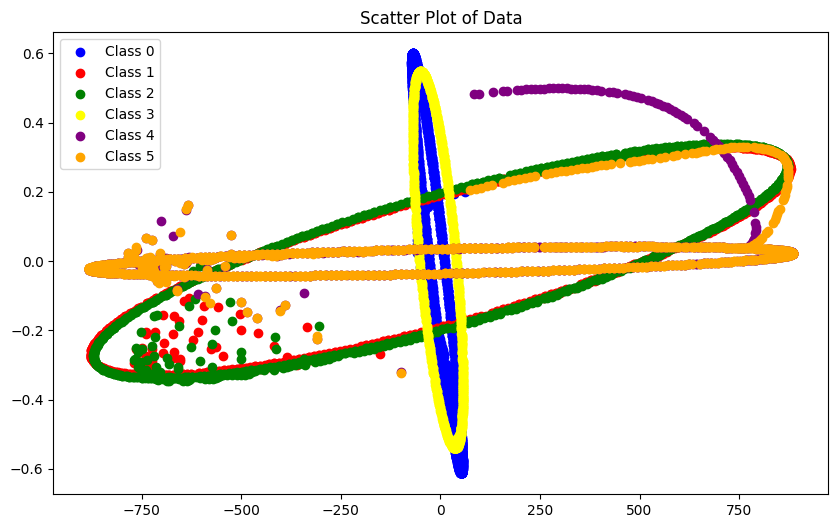

In [70]:
plotData(x_train, y_train)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_trainLR = best_model.predict(x_train)
y_pred_testLR = best_model.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_testKNN))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_testKNN))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_testKNN))

Best Parameters:
{'model__C': 100, 'model__solver': 'lbfgs'}
Accuracy: 0.8925619834710744

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       473
           1       0.97      1.00      0.98       226
           2       1.00      0.96      0.98       227
           3       1.00      1.00      1.00       201
           4       0.63      0.65      0.64       219
           5       0.65      0.63      0.64       227

    accuracy                           0.89      1573
   macro avg       0.87      0.87      0.87      1573
weighted avg       0.89      0.89      0.89      1573


Confusion Matrix:
[[473   0   0   0   0   0]
 [  0 226   0   0   0   0]
 [  0   7 219   0   0   1]
 [  0   0   0 201   0   0]
 [  0   0   0   0 143  76]
 [  0   0   0   0  85 142]]


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# GridSearch
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

# Prediction
y_pred_testKNN = best_model.predict(x_test)
y_pred_trainKNN = best_model.predict(x_train)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_testKNN))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_testKNN))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_testKNN))

Best Parameters:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Accuracy: 0.8925619834710744

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       473
           1       0.97      1.00      0.98       226
           2       1.00      0.96      0.98       227
           3       1.00      1.00      1.00       201
           4       0.63      0.65      0.64       219
           5       0.65      0.63      0.64       227

    accuracy                           0.89      1573
   macro avg       0.87      0.87      0.87      1573
weighted avg       0.89      0.89      0.89      1573


Confusion Matrix:
[[473   0   0   0   0   0]
 [  0 226   0   0   0   0]
 [  0   7 219   0   0   1]
 [  0   0   0 201   0   0]
 [  0   0   0   0 143  76]
 [  0   0   0   0  85 142]]


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_testDT = best_model.predict(x_test)
y_pred_trainDT = best_model.predict(x_train)
# 6. Best CV score
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)
print("\nAccuracy:", accuracy_score(y_test, y_pred_testDT))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_testDT))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_testDT))


Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.8732508445550703

Accuracy: 0.18308963763509217

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       473
           1       0.11      0.11      0.11       226
           2       0.00      0.00      0.00       227
           3       0.12      0.37      0.18       201
           4       0.08      0.08      0.08       219
           5       0.32      0.76      0.45       227

    accuracy                           0.18      1573
   macro avg       0.11      0.22      0.14      1573
weighted avg       0.09      0.18      0.11      1573


Confusion Matrix:
[[  0 185   0 242   3  43]
 [  0  24   0 120  53  29]
 [  0   0   0 108  78  41]
 [  0   2   0  74  31  94]
 [  0   0   0  34  17 168]
 [  0   0   0  31  23 173]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resul

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create Random Forest
model = RandomForestClassifier(
    random_state=42
)

# 2. Parameters to search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5]
}

# 3. Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Train
grid_search.fit(x_train, y_train)

# 5. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# 6. Best CV score
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# 7. Best model
best_model = grid_search.best_estimator_

# 8. Prediction on test data
y_pred_testRF = best_model.predict(x_test)
y_pred_trainRF = best_model.predict(x_train)

# 9. Test Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

# 10. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.8562340966921119

Test Accuracy:
0.18308963763509217

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       473
           1       0.11      0.11      0.11       226
           2       0.00      0.00      0.00       227
           3       0.12      0.37      0.18       201
           4       0.08      0.08      0.08       219
           5       0.32      0.76      0.45       227

    accuracy                           0.18      1573
   macro avg       0.11      0.22      0.14      1573
weighted avg       0.09      0.18      0.11      1573


Confusion Matrix:
[[  0 185   0 242   3  43]
 [  0  24   0 120  53  29]
 [  0   0   0 108  78  41]
 [  0   2   0  74  31  94]
 [  0   0   0  34  17 168]
 [  0   0   0  31  23 173]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [89]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Create model
model = GaussianNB()

# 2. Parameters to search
param_grid = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Train
grid_search.fit(x_train, y_train)

# 5. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# 6. Best CV score
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# 7. Best model
best_model = grid_search.best_estimator_

# 8. Prediction
y_pred_testNB = best_model.predict(x_test)
y_pred_trainNB = best_model.predict(x_train)

# 9. Test Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

# 10. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters:
{'var_smoothing': 1e-09}

Best Cross-Validation Accuracy:
0.7985056655701047

Test Accuracy:
0.18308963763509217

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       473
           1       0.11      0.11      0.11       226
           2       0.00      0.00      0.00       227
           3       0.12      0.37      0.18       201
           4       0.08      0.08      0.08       219
           5       0.32      0.76      0.45       227

    accuracy                           0.18      1573
   macro avg       0.11      0.22      0.14      1573
weighted avg       0.09      0.18      0.11      1573


Confusion Matrix:
[[  0 185   0 242   3  43]
 [  0  24   0 120  53  29]
 [  0   0   0 108  78  41]
 [  0   2   0  74  31  94]
 [  0   0   0  34  17 168]
 [  0   0   0  31  23 173]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [90]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# 2. Parameters to search
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__kernel': ['rbf'],
    'svm__gamma': ['scale', 'auto']
}

# 3. GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. Train
grid_search.fit(x_train, y_train)

# 5. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# 6. Best CV accuracy
print("\nBest Cross-Validation Accuracy:")
print(grid_search.best_score_)

# 7. Best model
best_model = grid_search.best_estimator_

# 8. Prediction
y_pred_testSVM = best_model.predict(x_test)
y_pred_trainSVM = best_model.predict(x_train)

# 9. Test Accuracy
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

# 10. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 11. Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters:
{'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Best Cross-Validation Accuracy:
0.8532133565546453

Test Accuracy:
0.18308963763509217

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       473
           1       0.11      0.11      0.11       226
           2       0.00      0.00      0.00       227
           3       0.12      0.37      0.18       201
           4       0.08      0.08      0.08       219
           5       0.32      0.76      0.45       227

    accuracy                           0.18      1573
   macro avg       0.11      0.22      0.14      1573
weighted avg       0.09      0.18      0.11      1573


Confusion Matrix:
[[  0 185   0 242   3  43]
 [  0  24   0 120  53  29]
 [  0   0   0 108  78  41]
 [  0   2   0  74  31  94]
 [  0   0   0  34  17 168]
 [  0   0   0  31  23 173]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV F1-score:
0.8558607709114573

Accuracy: 0.8575969485060394
F1-score: 0.8571366384788683

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       473
           1       0.99      1.00      0.99       226
           2       1.00      0.99      0.99       227
           3       1.00      1.00      1.00       201
           4       0.50      0.55      0.52       219
           5       0.51      0.46      0.48       227

    accuracy                           0.86      1573
   macro avg       0.83      0.83      0.83      1573
weighted avg       0.86      0.86      0.86      1573


Confusion Matrix:
[[473   0   0   0   0   0]
 [  0 226   0   0   0   0]
 [  0   3 224   0   0   0]
 [  0   0   0 201   0   0]
 [  0   0   0   0 121  98]
 [  0   0   1   0 122 104]]


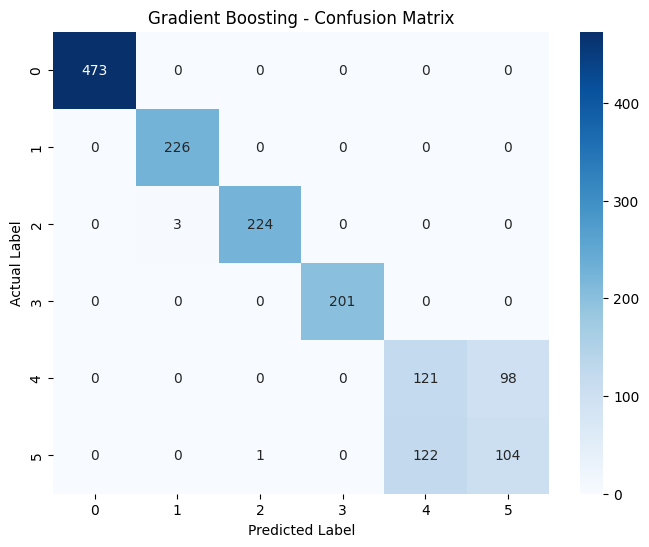

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_testGB = best_model.predict(x_test)
y_pred_trainGB = best_model.predict(x_train)

print("\nAccuracy:", accuracy_score(y_test, y_pred_testGB))
print("F1-score:", f1_score(y_test, y_pred_testGB, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_testGB))

cm = confusion_matrix(y_test, y_pred_testGB)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

Best Parameters:
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}

Best CV F1-score:
0.9640416732950909

Accuracy: 0.9497774952320407
F1-score: 0.949629977184576

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       473
           1       0.98      1.00      0.99       226
           2       0.99      0.98      0.98       227
           3       0.99      1.00      0.99       201
           4       0.84      0.84      0.84       219
           5       0.85      0.83      0.84       227

    accuracy                           0.95      1573
   macro avg       0.94      0.94      0.94      1573
weighted avg       0.95      0.95      0.95      1573


Confusion Matrix:
[[472   0   0   0   1   0]
 [  0 225   1   0   0   0]
 [  0   3 222   0   0   2]
 [  0   0   0 201   0   0]
 [  0   0   0   2 185  32]
 [  0   1   2   1  34 189]]


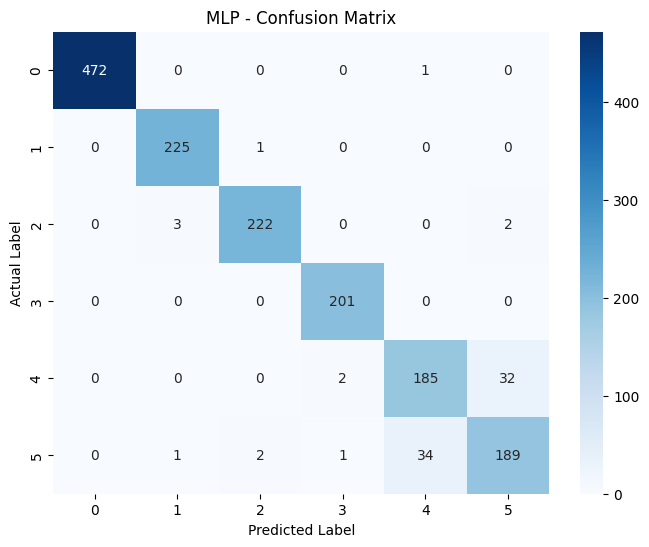

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = MLPClassifier(
    random_state=42,
    max_iter=500
)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_testMLP = best_model.predict(x_test)
y_pred_trainMLP = best_model.predict(x_train)

print("\nAccuracy:", accuracy_score(y_test, y_pred_testMLP))
print("F1-score:", f1_score(y_test, y_pred_testMLP, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_testMLP))

cm = confusion_matrix(y_test, y_pred_testMLP)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MLP - Confusion Matrix")
plt.show()